/tmp/ipykernel_1278/1714347759.py:12: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['Date'] = pd.to_datetime(df['Date'])


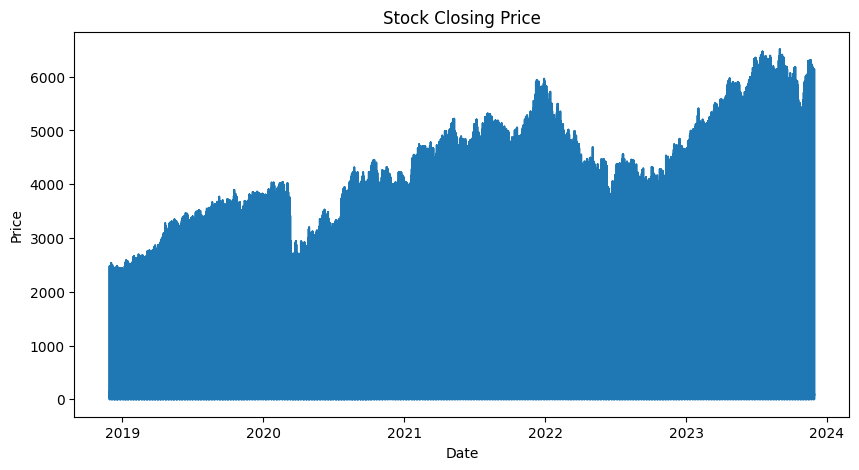

MAE : 127.50275605831172
MSE : 121396.95645102444
RMSE: 348.4206601954374


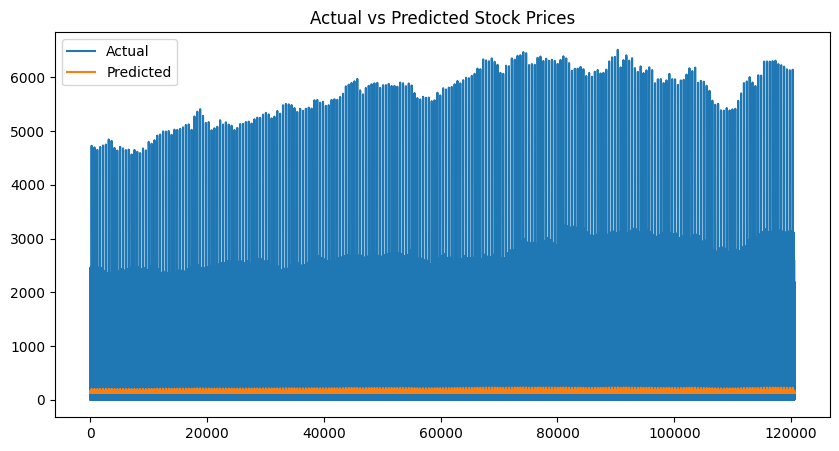

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load Dataset
df = pd.read_csv("/content/archive (5).zip")

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# Visualize Stock Prices
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Close'])
plt.title("Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

# Create Previous Day Feature
df['Prev_Close'] = df['Close'].shift(1)
df.dropna(inplace=True)

X = df[['Prev_Close']]
y = df['Close']

# Chronological Split
split = int(len(df) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
predictions = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)

# Plot Actual vs Predicted
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(predictions, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Stock Prices")
plt.show()